In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,auc
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize

In [24]:
dataset_path = "C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/Datasets/Img"

files = os.listdir(dataset_path)

print("Total files:", len(files))

print("\nFirst 20 files:")

for file in files[:20]:
    print(file)

Total files: 1212

First 20 files:
img001-001.png
img001-002.png
img001-003.png
img001-004.png
img001-005.png
img001-006.png
img001-007.png
img001-008.png
img001-009.png
img001-010.png
img001-011.png
img001-012.png
img001-013.png
img001-014.png
img001-015.png
img001-016.png
img001-017.png
img001-018.png
img001-019.png
img001-020.png


In [25]:
images = []
labels = []

for file_name in files:

    file_path = os.path.join(dataset_path, file_name)

    if not file_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    try:

        image = Image.open(file_path)

        image = image.convert("L")

        image = image.resize((28, 28))

        image_array = np.array(image)

        images.append(image_array)

        label = file_name.split("-")[0]

        labels.append(label)

    except:
        print("Could not read:", file_name)

X = np.array(images)
y = np.array(labels)

print("Number of images:", len(X))
print("Image shape:", X.shape)
print("Number of labels:", len(y))

Number of images: 1212
Image shape: (1212, 28, 28)
Number of labels: 1212


In [20]:
label_counts = Counter(y)

print("Number of classes:", len(label_counts))
print("Number of images:", len(y))

print("\nClasses with fewer than 2 images:")

for label, count in label_counts.items():
    if count < 2:
        print(label, ":", count)

Number of classes: 1212
Number of images: 1212

Classes with fewer than 2 images:
img001-001.png : 1
img001-002.png : 1
img001-003.png : 1
img001-004.png : 1
img001-005.png : 1
img001-006.png : 1
img001-007.png : 1
img001-008.png : 1
img001-009.png : 1
img001-010.png : 1
img001-011.png : 1
img001-012.png : 1
img001-013.png : 1
img001-014.png : 1
img001-015.png : 1
img001-016.png : 1
img001-017.png : 1
img001-018.png : 1
img001-019.png : 1
img001-020.png : 1
img001-021.png : 1
img001-022.png : 1
img001-023.png : 1
img001-024.png : 1
img001-025.png : 1
img001-026.png : 1
img001-027.png : 1
img001-028.png : 1
img001-029.png : 1
img001-030.png : 1
img001-031.png : 1
img001-032.png : 1
img001-033.png : 1
img001-034.png : 1
img001-035.png : 1
img001-036.png : 1
img001-037.png : 1
img001-038.png : 1
img001-039.png : 1
img001-040.png : 1
img001-041.png : 1
img001-042.png : 1
img001-043.png : 1
img001-044.png : 1
img001-045.png : 1
img001-046.png : 1
img001-047.png : 1
img001-048.png : 1
img001

In [22]:
print("First 20 labels:")
print(y[:20])

print("\nNumber of different classes:")
print(len(np.unique(y)))

print("\nClasses:")
print(np.unique(y))

X shape: (1212, 784)
y shape: (1212,)

First 20 labels:
['img001-001.png' 'img001-002.png' 'img001-003.png' 'img001-004.png'
 'img001-005.png' 'img001-006.png' 'img001-007.png' 'img001-008.png'
 'img001-009.png' 'img001-010.png' 'img001-011.png' 'img001-012.png'
 'img001-013.png' 'img001-014.png' 'img001-015.png' 'img001-016.png'
 'img001-017.png' 'img001-018.png' 'img001-019.png' 'img001-020.png']


In [26]:
print("First 20 labels:")
print(y[:20])

print("\nNumber of different classes:")
print(len(np.unique(y)))

print("\nClasses:")
print(np.unique(y))

First 20 labels:
['img001' 'img001' 'img001' 'img001' 'img001' 'img001' 'img001' 'img001'
 'img001' 'img001' 'img001' 'img001' 'img001' 'img001' 'img001' 'img001'
 'img001' 'img001' 'img001' 'img001']

Number of different classes:
23

Classes:
['img001' 'img002' 'img003' 'img004' 'img005' 'img006' 'img007' 'img008'
 'img009' 'img010' 'img011' 'img012' 'img013' 'img014' 'img015' 'img016'
 'img017' 'img018' 'img019' 'img020' 'img021' 'img022' 'img023']


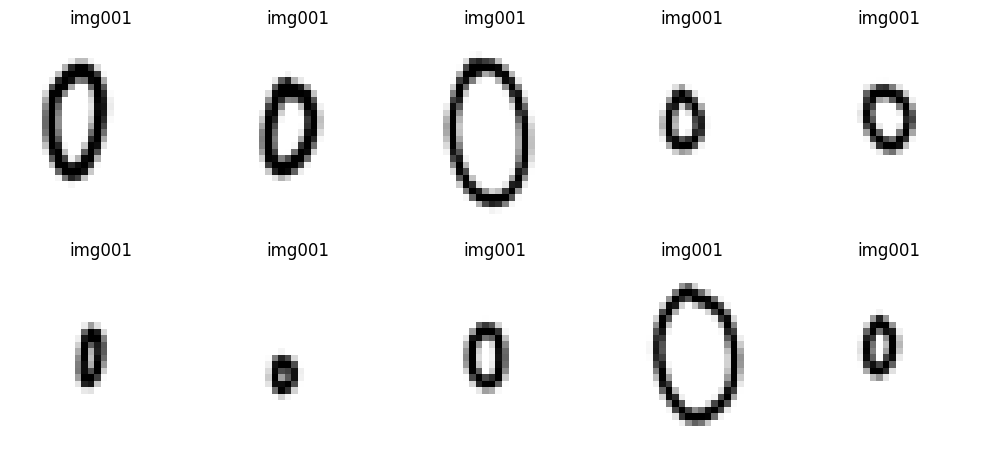

In [87]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X[i], cmap="gray")

    plt.title(y[i])

    plt.axis("off")

plt.tight_layout()
plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/image.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [31]:
X = X.reshape(X.shape[0], -1)

print("New image shape:", X.shape)

New image shape: (1212, 784)


In [32]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Number of classes:", len(encoder.classes_))

print("Class names:")
print(encoder.classes_)

Number of classes: 23
Class names:
['img001' 'img002' 'img003' 'img004' 'img005' 'img006' 'img007' 'img008'
 'img009' 'img010' 'img011' 'img012' 'img013' 'img014' 'img015' 'img016'
 'img017' 'img018' 'img019' 'img020' 'img021' 'img022' 'img023']


In [33]:
unique, counts = np.unique(y, return_counts=True)

print("Images in each class:\n")

for label, count in zip(unique, counts):
    print(label, ":", count)

Images in each class:

0 : 55
1 : 55
2 : 55
3 : 55
4 : 55
5 : 55
6 : 55
7 : 55
8 : 55
9 : 55
10 : 55
11 : 55
12 : 55
13 : 55
14 : 55
15 : 55
16 : 55
17 : 55
18 : 55
19 : 55
20 : 55
21 : 55
22 : 2


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [46]:
class SimplePerceptron:

    def __init__(self, learning_rate=0.01, epochs=10):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.errors = []

    def fit(self, X, y):

        number_of_classes = len(np.unique(y))

        number_of_features = X.shape[1]
        self.weights = np.zeros((number_of_classes, number_of_features))
        self.bias = np.zeros(number_of_classes)

        for epoch in range(self.epochs):

            errors = 0

            for i in range(len(X)):
                scores = np.dot(self.weights,X[i]) + self.bias

                prediction = np.argmax(scores)

                actual = y[i]

                if prediction != actual:

                    self.weights[actual] += ( self.learning_rate * X[i])

                    self.weights[prediction] -= (self.learning_rate * X[i])

                    self.bias[actual] += self.learning_rate

                    self.bias[prediction] -= self.learning_rate

                    errors += 1

            self.errors.append(errors)

            print("Epoch",epoch + 1,"Errors:",errors)

        return self

    def predict(self, X):

        scores = np.dot(X,self.weights.T) + self.bias

        return np.argmax(scores, axis=1)

In [48]:
pla = SimplePerceptron(learning_rate=0.01,epochs=10)

pla.fit(X_train, y_train)

Epoch 1 Errors: 925
Epoch 2 Errors: 887
Epoch 3 Errors: 845
Epoch 4 Errors: 799
Epoch 5 Errors: 781
Epoch 6 Errors: 756
Epoch 7 Errors: 729
Epoch 8 Errors: 704
Epoch 9 Errors: 714
Epoch 10 Errors: 703


In [50]:
y_pred_pla = pla.predict(X_test)

print("PLA predictions:")
print(y_pred_pla[:20])

PLA predictions:
[10  7  7  7  7 16  4  3  7  7  7  7  7  7  7  4  7  7  7  7]


In [51]:
pla_accuracy = accuracy_score(y_test,y_pred_pla)

pla_precision = precision_score(y_test,y_pred_pla,average="macro",zero_division=0)

pla_recall = recall_score(y_test,y_pred_pla,average="macro",zero_division=0)

pla_f1 = f1_score(y_test,y_pred_pla,average="macro",zero_division=0)

print("\nPLA Results")

print("Accuracy :", round(pla_accuracy, 4))
print("Precision:", round(pla_precision, 4))
print("Recall   :", round(pla_recall, 4))
print("F1 Score :", round(pla_f1, 4))


PLA Results
---------------------
Accuracy : 0.1605
Precision: 0.1973
Recall   : 0.1542
F1 Score : 0.1372


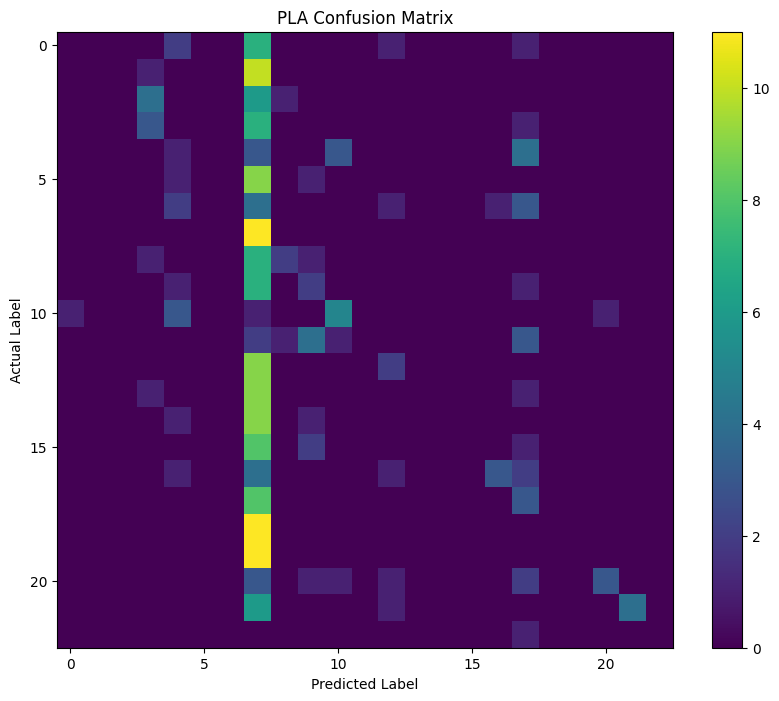

In [89]:
cm_pla = confusion_matrix(y_test,y_pred_pla)

plt.figure(figsize=(10, 8))

plt.imshow(cm_pla)

plt.title("PLA Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/pla_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

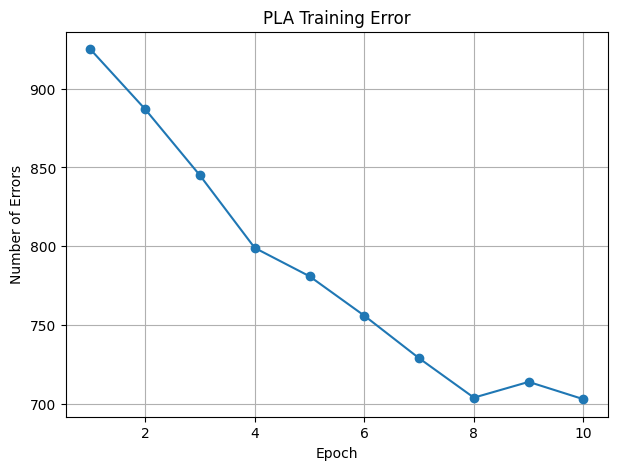

In [88]:
plt.figure(figsize=(7, 5))

plt.plot(range(1, len(pla.errors) + 1),pla.errors,marker="o")

plt.xlabel("Epoch")
plt.ylabel("Number of Errors")

plt.title("PLA Training Error")

plt.grid()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/pla_training_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
mlp = MLPClassifier(hidden_layer_sizes=(128,),activation="relu",solver="adam",learning_rate_init=0.001,batch_size=32,max_iter=30,random_state=42,verbose=True)

mlp.fit(X_train, y_train)

Iteration 1, loss = 3.26481578
Iteration 2, loss = 3.10241889
Iteration 3, loss = 3.07205133
Iteration 4, loss = 3.00203292
Iteration 5, loss = 2.98723692
Iteration 6, loss = 2.94041798
Iteration 7, loss = 2.88860861
Iteration 8, loss = 2.84038735
Iteration 9, loss = 2.77667605
Iteration 10, loss = 2.73626394
Iteration 11, loss = 2.67552358
Iteration 12, loss = 2.66573086
Iteration 13, loss = 2.60428417
Iteration 14, loss = 2.54114131
Iteration 15, loss = 2.48463809
Iteration 16, loss = 2.43619462
Iteration 17, loss = 2.39847554
Iteration 18, loss = 2.34691634
Iteration 19, loss = 2.31451714
Iteration 20, loss = 2.25321083
Iteration 21, loss = 2.27576780
Iteration 22, loss = 2.18302389
Iteration 23, loss = 2.16397287
Iteration 24, loss = 2.12349647
Iteration 25, loss = 2.10665619
Iteration 26, loss = 2.08534706
Iteration 27, loss = 2.04541368
Iteration 28, loss = 2.02981789
Iteration 29, loss = 1.97022498
Iteration 30, loss = 1.93820520


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=32, hidden_layer_sizes=(128,), max_iter=30,
              random_state=42, verbose=True)

In [55]:
y_pred_mlp = mlp.predict(X_test)

print("First 20 predictions:")
print(y_pred_mlp[:20])

First 20 predictions:
[10  8 20  1 12 16  6  1  5  1 17  4  1 16  5 16 15 12  7  5]


In [56]:
mlp_accuracy = accuracy_score(y_test,y_pred_mlp)

mlp_precision = precision_score(y_test,y_pred_mlp,average="macro",zero_division=0)

mlp_recall = recall_score(y_test,y_pred_mlp,average="macro",zero_division=0)

mlp_f1 = f1_score(y_test,y_pred_mlp,average="macro",zero_division=0)

print("\nMLP Results")
print("---------------------")

print("Accuracy :", round(mlp_accuracy, 4))
print("Precision:", round(mlp_precision, 4))
print("Recall   :", round(mlp_recall, 4))
print("F1 Score :", round(mlp_f1, 4))


MLP Results
---------------------
Accuracy : 0.3868
Precision: 0.4614
Recall   : 0.3715
F1 Score : 0.3667


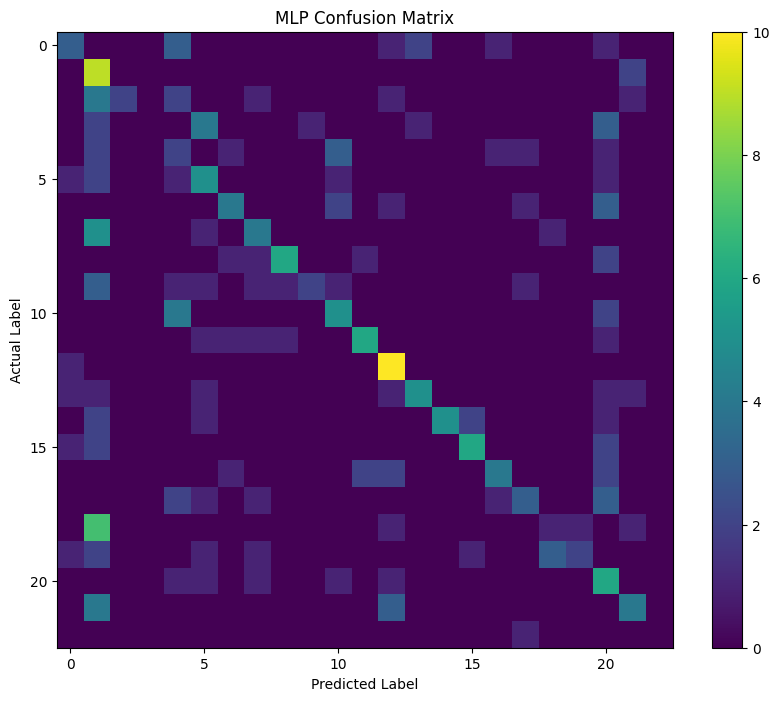

In [90]:
cm_mlp = confusion_matrix(y_test,y_pred_mlp)

plt.figure(figsize=(10, 8))

plt.imshow(cm_mlp)

plt.title("MLP Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/mlp_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

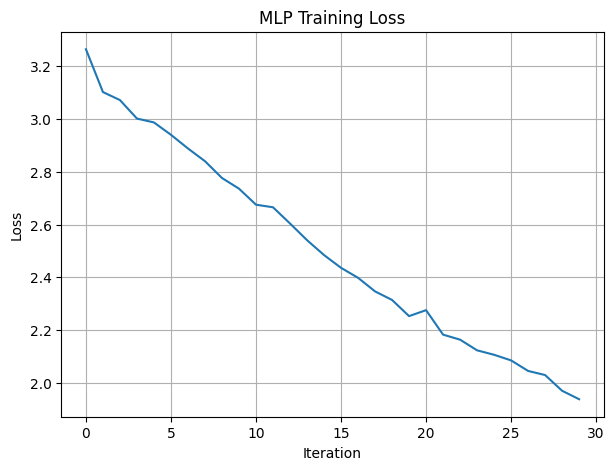

In [91]:
plt.figure(figsize=(7, 5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title("MLP Training Loss")

plt.grid()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/mlp_training_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
settings = [

    {
        "activation": "relu",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "activation": "relu",
        "solver": "sgd",
        "learning_rate": 0.01,
        "batch_size": 32
    },

    {
        "activation": "tanh",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "activation": "relu",
        "solver": "adam",
        "learning_rate": 0.0001,
        "batch_size": 64
    }
]

In [60]:
results = []

for setting in settings:
    print("Testing:", setting)

    model = MLPClassifier(hidden_layer_sizes=(128,),activation=setting["activation"],solver=setting["solver"],learning_rate_init=setting["learning_rate"],batch_size=setting["batch_size"],max_iter=30,random_state=42)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test,predictions)

    results.append({"Activation": setting["activation"],"Optimizer": setting["solver"],"Learning Rate": setting["learning_rate"],"Batch Size": setting["batch_size"],"Accuracy": accuracy})

    print("Accuracy:",round(accuracy, 4))

Testing: {'activation': 'relu', 'solver': 'adam', 'learning_rate': 0.001, 'batch_size': 32}


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.3868
Testing: {'activation': 'relu', 'solver': 'sgd', 'learning_rate': 0.01, 'batch_size': 32}


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.4198
Testing: {'activation': 'tanh', 'solver': 'adam', 'learning_rate': 0.001, 'batch_size': 32}


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.4444
Testing: {'activation': 'relu', 'solver': 'adam', 'learning_rate': 0.0001, 'batch_size': 64}
Accuracy: 0.2634


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [62]:
results_df = pd.DataFrame(results)

print(results_df)

  Activation Optimizer  Learning Rate  Batch Size  Accuracy
0       relu      adam         0.0010          32  0.386831
1       relu       sgd         0.0100          32  0.419753
2       tanh      adam         0.0010          32  0.444444
3       relu      adam         0.0001          64  0.263374


In [63]:
best_row = results_df.loc[results_df["Accuracy"].idxmax()]

print("Chosen configuration:")
print(best_row)

Chosen configuration:
Activation           tanh
Optimizer            adam
Learning Rate       0.001
Batch Size             32
Accuracy         0.444444
Name: 2, dtype: object


In [64]:
best_mlp = MLPClassifier(hidden_layer_sizes=(128,),activation=best_row["Activation"],solver=best_row["Optimizer"],learning_rate_init=best_row["Learning Rate"],batch_size=int(best_row["Batch Size"]),max_iter=50,random_state=42,verbose=True)

best_mlp.fit(X_train, y_train)

Iteration 1, loss = 3.26324687
Iteration 2, loss = 3.09345592
Iteration 3, loss = 3.06048736
Iteration 4, loss = 3.00521017
Iteration 5, loss = 2.96536477
Iteration 6, loss = 2.90723512
Iteration 7, loss = 2.83432531
Iteration 8, loss = 2.77743673
Iteration 9, loss = 2.70478501
Iteration 10, loss = 2.63482022
Iteration 11, loss = 2.59672403
Iteration 12, loss = 2.53309904
Iteration 13, loss = 2.55287886
Iteration 14, loss = 2.40109240
Iteration 15, loss = 2.35746681
Iteration 16, loss = 2.32077455
Iteration 17, loss = 2.24562768
Iteration 18, loss = 2.20786299
Iteration 19, loss = 2.18088760
Iteration 20, loss = 2.13990363
Iteration 21, loss = 2.12663848
Iteration 22, loss = 2.02670772
Iteration 23, loss = 2.04168478
Iteration 24, loss = 1.99473581
Iteration 25, loss = 1.97724282
Iteration 26, loss = 1.94086055
Iteration 27, loss = 1.91725711
Iteration 28, loss = 1.85621791
Iteration 29, loss = 1.85667511
Iteration 30, loss = 1.79109476
Iteration 31, loss = 1.79570307
Iteration 32, los

C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='tanh', batch_size=32, hidden_layer_sizes=(128,),
              max_iter=50, random_state=42, verbose=True)

In [65]:
final_predictions = best_mlp.predict(X_test)

In [66]:
final_accuracy = accuracy_score(y_test,final_predictions)

final_precision = precision_score(y_test,final_predictions,average="macro",zero_division=0)

final_recall = recall_score(y_test,final_predictions,average="macro",zero_division=0)

final_f1 = f1_score(y_test,final_predictions,average="macro",zero_division=0)

print("\nFinal MLP Results")

print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))


Final MLP Results
---------------------
Accuracy : 0.4362
Precision: 0.467
Recall   : 0.419
F1 Score : 0.4187


In [67]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "PLA": [
        pla_accuracy,
        pla_precision,
        pla_recall,
        pla_f1
    ],

    "MLP": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print(comparison)

      Metric       PLA       MLP
0   Accuracy  0.160494  0.436214
1  Precision  0.197327  0.467042
2     Recall  0.154150  0.418972
3   F1 Score  0.137236  0.418680


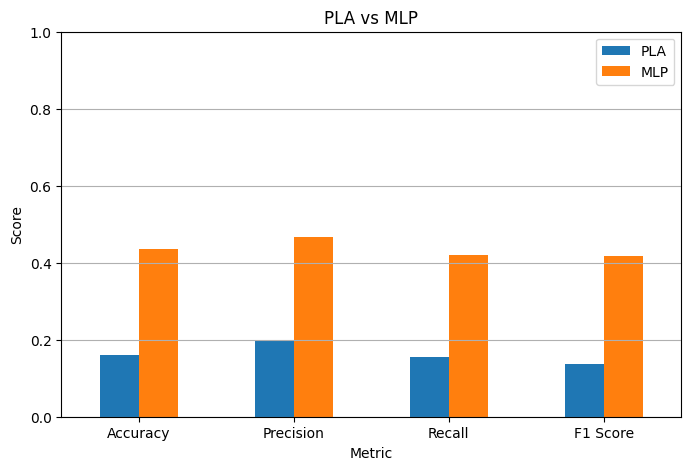

In [92]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot( kind="bar",figsize=(8, 5))

plt.title("PLA vs MLP")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/pla_vs_mlp.png", dpi=300, bbox_inches="tight")
plt.show()

In [69]:
print(classification_report(y_test,final_predictions,target_names=encoder.classes_,zero_division=0))

              precision    recall  f1-score   support

      img001       0.57      0.36      0.44        11
      img002       0.44      0.64      0.52        11
      img003       0.20      0.36      0.26        11
      img004       0.40      0.18      0.25        11
      img005       0.08      0.09      0.09        11
      img006       0.31      0.36      0.33        11
      img007       0.39      0.64      0.48        11
      img008       0.33      0.09      0.14        11
      img009       0.78      0.64      0.70        11
      img010       0.57      0.36      0.44        11
      img011       0.28      0.45      0.34        11
      img012       0.44      0.64      0.52        11
      img013       0.47      0.73      0.57        11
      img014       0.86      0.55      0.67        11
      img015       0.70      0.64      0.67        11
      img016       1.00      0.55      0.71        11
      img017       0.31      0.36      0.33        11
      img018       0.60    

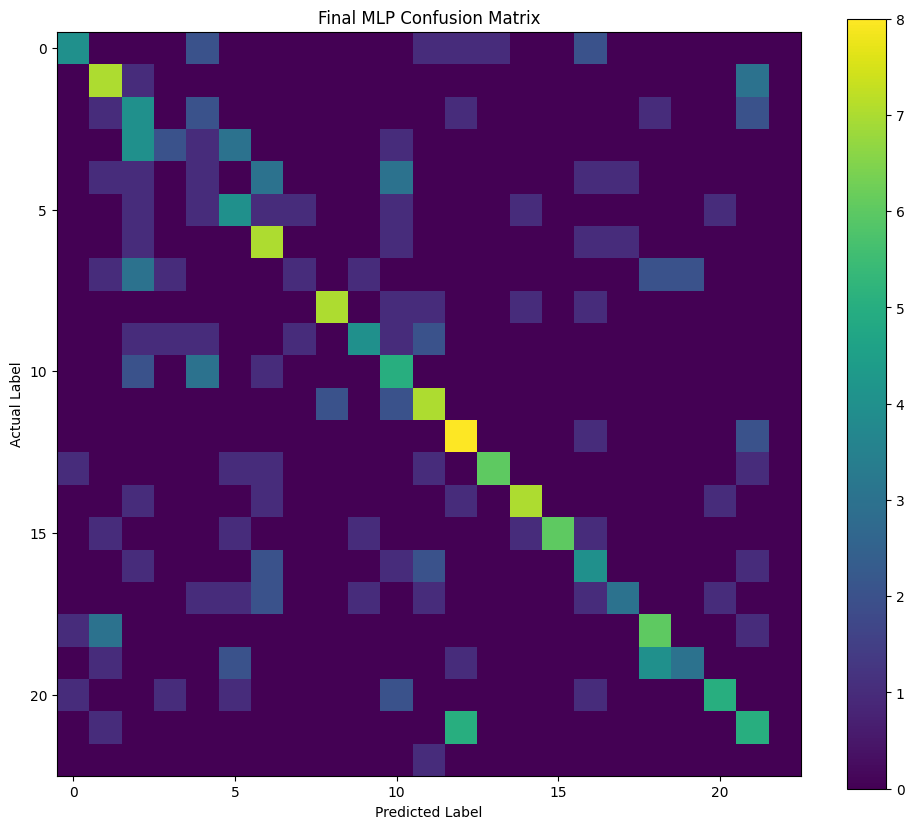

In [93]:
final_cm = confusion_matrix(y_test,final_predictions)

plt.figure(figsize=(12, 10))

plt.imshow(final_cm)

plt.title("Final MLP Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/mla_final_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:

y_test_binary = label_binarize(y_test,classes=np.arange(len(encoder.classes_)))

y_probability = best_mlp.predict_proba(X_test)

fpr, tpr, thresholds = roc_curve(y_test_binary.ravel(),y_probability.ravel())

roc_auc = auc(fpr, tpr)

print("Micro-average ROC AUC:", round(roc_auc, 4))

Micro-average ROC AUC: 0.8954


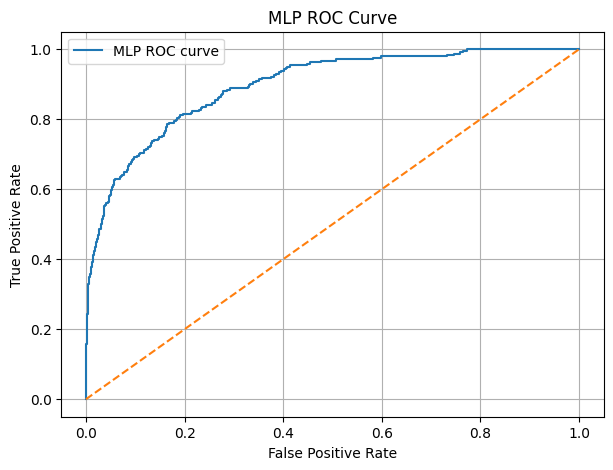

In [94]:
plt.figure(figsize=(7, 5))

plt.plot(fpr,tpr,label="MLP ROC curve")

plt.plot([0, 1],[0, 1],linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MLP ROC Curve")

plt.legend()

plt.grid()

plt.savefig("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_9/output_plots/mlp_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:
comparison.to_csv("PLA_vs_MLP_results.csv",index=False)

results_df.to_csv("MLP_hyperparameter_results.csv",index=False)

print("Results saved successfully.")

Results saved successfully.
